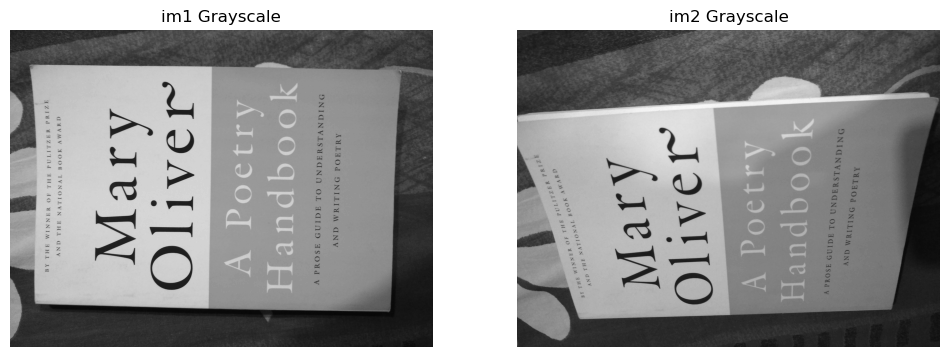

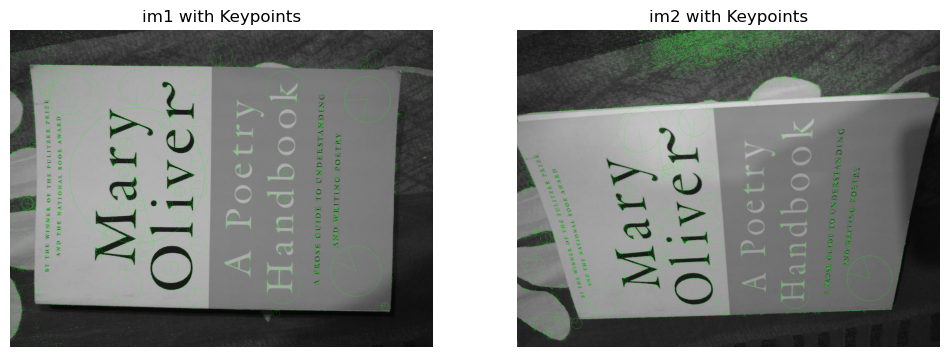

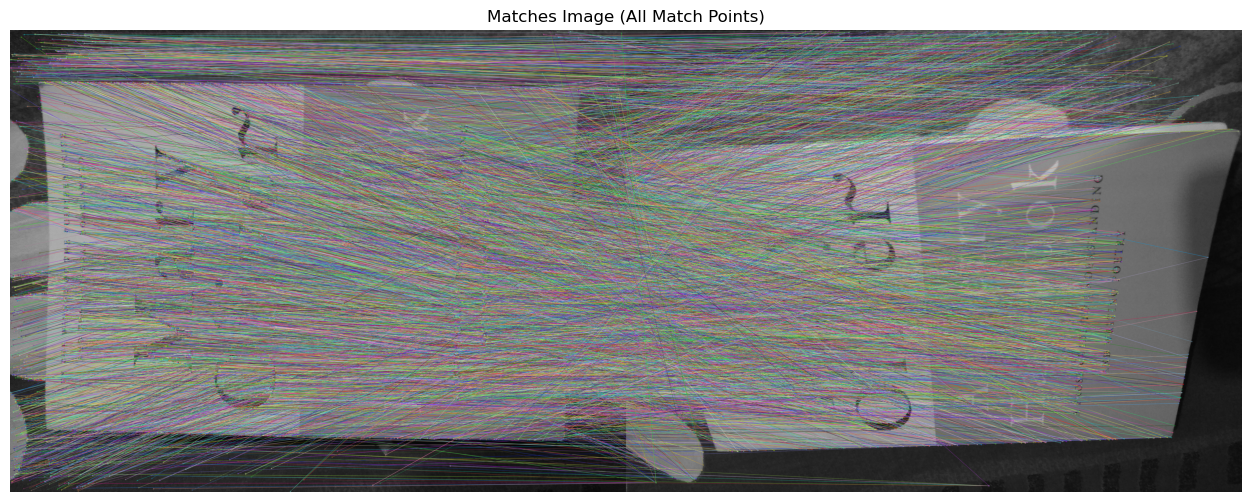

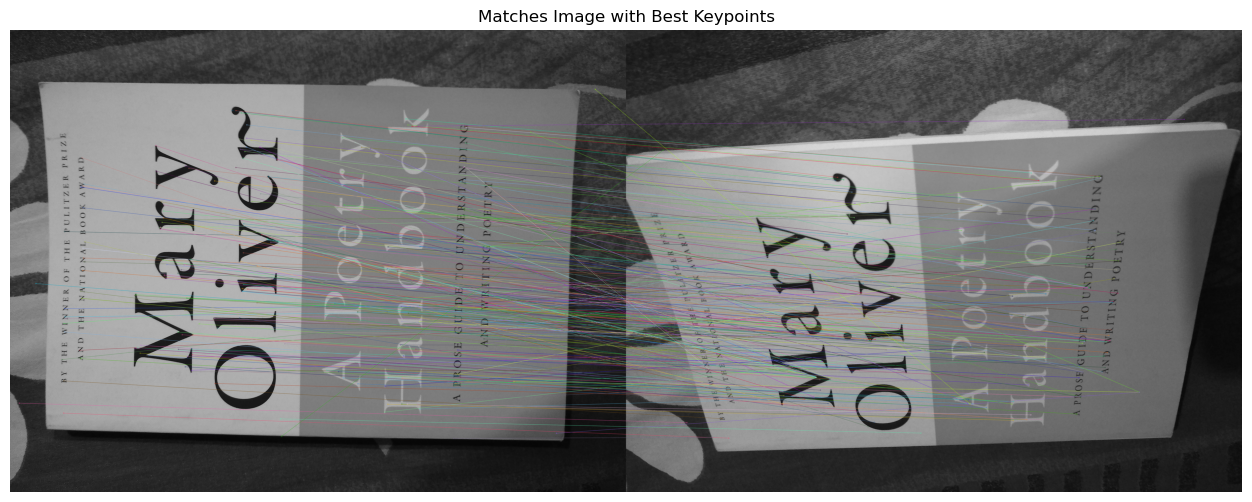

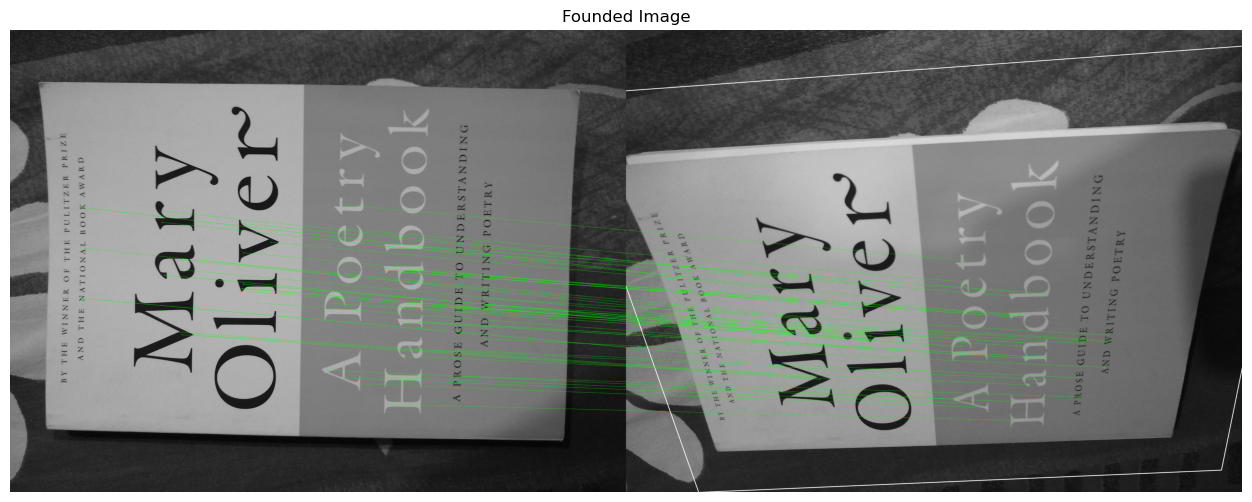

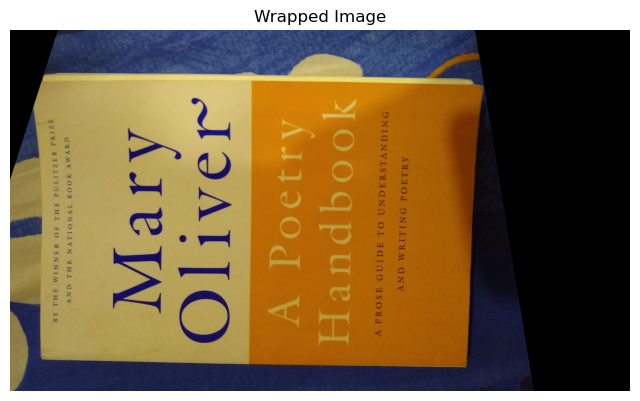

In [1]:
# Importing necessary libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Minimum number of matches required for homography calculation
MIN_MATCH_COUNT = 10 

# Reading the input images
im1 = cv2.imread('im1.jpg')
im2 = cv2.imread('im2.jpg')

# Converting the images to grayscale
img1 = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

# Setting the figure size for the subplot
plt.figure(figsize=(12, 6))

# Plotting the grayscale images in a 1x2 subplot
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('im1 Grayscale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title('im2 Grayscale')
plt.axis('off')

# Initiating SIFT detector
sift = cv2.SIFT_create()

# Finding keypoints and descriptors using SIFT
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Saving keypoints in text files for both images
keypoints_file_im1 = 'keypoints_im1_gray.txt'
with open(keypoints_file_im1, 'w') as f:
    for kp in kp1:
        f.write(f"{kp.pt[0]},{kp.pt[1]}\n")

keypoints_file_im2 = 'keypoints_im2_gray.txt'
with open(keypoints_file_im2, 'w') as f:
    for kp in kp2:
        f.write(f"{kp.pt[0]},{kp.pt[1]}\n")

# Drawing keypoints on both images
im1_keypoints = cv2.drawKeypoints(img1, kp1, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
im2_keypoints = cv2.drawKeypoints(img2, kp2, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Displaying the images with keypoints in a 1x2 subplot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(im1_keypoints)
plt.title('im1 with Keypoints')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(im2_keypoints)
plt.title('im2 with Keypoints')
plt.axis('off')

# FLANN parameters for feature matching
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# Keepping all match points
all_matches = [m[0] for m in matches]

# Drawing all matches on the images
matches_img = cv2.drawMatches(img1, kp1, img2, kp2, all_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Displaying the matches image using matplotlib
plt.figure(figsize=(20, 6))
plt.imshow(matches_img)
plt.title('Matches Image (All Match Points)')
plt.axis('off')

# Keepping only good matches based on Lowe's ratio test
good = [m for m, n in matches if m.distance < 0.7 * n.distance]

# Keepping the best keypoints
best_keypoints1 = [kp1[match.queryIdx] for match in good]
best_keypoints2 = [kp2[match.trainIdx] for match in good]

# Drawing matches with the best keypoints on the images
matches_img = cv2.drawMatches(img1, kp1, img2, kp2, good, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Displaying the matches image 
plt.figure(figsize=(20, 6))
plt.imshow(matches_img)
plt.title('Matches Image with Best Keypoints')
plt.axis('off')

# Checking if there are enough good matches for homography calculation
if len(good) > MIN_MATCH_COUNT:
    # Getting source and destination points for homography calculation
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    
    # Finding homography matrix using RANSAC
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matchesMask = mask.ravel().tolist()
    
    # Getting the dimensions for the warped image
    h, w = img1.shape
    pts = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
    input_pts = cv2.perspectiveTransform(pts, M)

    # Calculating the width and height of the area which should be warped 
    width_AD = np.sqrt(((input_pts[0][0][0] - input_pts[3][0][0]) ** 2) + ((input_pts[0][0][1] - input_pts[3][0][1]) ** 2))
    width_BC = np.sqrt(((input_pts[1][0][0] - input_pts[2][0][0]) ** 2) + ((input_pts[1][0][1] - input_pts[2][0][1]) ** 2))
    maxWidth = max(int(width_AD), int(width_BC))

    height_AB = np.sqrt(((input_pts[0][0][0] - input_pts[1][0][0]) ** 2) + ((input_pts[0][0][1] - input_pts[1][0][1]) ** 2))
    height_CD = np.sqrt(((input_pts[2][0][0] - input_pts[3][0][0]) ** 2) + ((input_pts[2][0][1] - input_pts[3][0][1]) ** 2))
    maxHeight = max(int(height_AB), int(height_CD))

    original_img2 = img2.copy()

    # Drawing the perspective-transformed points on the second image
    img2 = cv2.polylines(img2, [np.int32(input_pts)], True, 255, 3, cv2.LINE_AA)

else:
    print("Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT))
    matchesMask = None

# Drawing inlier matches on the images
draw_params = dict(matchColor=(0, 255, 0),  # draw matches in green color
                   singlePointColor=None,
                   matchesMask=matchesMask,  # draw only inliers
                   flags=2)
img3 = cv2.drawMatches(img1, kp1, img2, kp2, good, None, **draw_params)

# Displaying the final image with inlier matches
plt.figure(figsize=(20, 6))
plt.imshow(img3, cmap='gray') 
plt.title('Founded Image')
plt.axis('off')

# Warping the second image using the inverse homography matrix
out = cv2.warpPerspective(cv2.cvtColor(im2, cv2.COLOR_BGR2RGB), np.linalg.inv(M), (maxWidth, maxHeight), flags=cv2.INTER_LINEAR)

# Displaying the wrapped image after perspective transformation
plt.figure(figsize=(8, 6))
plt.imshow(out, cmap='gray') 
plt.title('Wrapped Image')
plt.axis('off')

# Showing all plots
plt.show() 
